<a href="https://colab.research.google.com/github/Jowwaannn/clinical-trial-ner/blob/main/notebooks/01_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CHIA Eligibility-Criteria NER: Stage 3 (Data Collection & Analysis)**

**Problem:** find and label medical entities (conditions, drugs, procedures, etc.) in clinical-trial eligibility criteria text.

**Dataset:** CHIA (Without Scope version): 1,000 trials, 2,000 documents (one inclusion and one exclusion file per trial), 12,409 criteria.

**Labels:** 44,616 annotated spans. 40,976 are real entities from 15 types (the target). 3,640 are annotator flags that I exclude.

**Class imbalance:** Condition makes up about 29% of entities, while Visit, Device and Mood are rare.

**Complications:** 1,796 entities are split into multiple pieces and 5,911 (14.4%) overlap another entity. This will be handled before model training.

**Split:** 80/10/10 by trial (seed 42): 800 / 100 / 100 trials (1,600 / 200 / 200 documents).**

### **1. Setup & Reproducibility**

In [19]:
# Connecting Drive

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/clinical-trial-ner'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Installing Libraries

!pip install transformers datasets seqeval

In [21]:
# Seeding
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [22]:
# Printing Versions
import sys, transformers, datasets, pandas, matplotlib
print("Python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("pandas:", pandas.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.13.15
torch: 2.11.0+cpu
transformers: 5.17.0
datasets: 4.8.5
pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0


In [23]:
!ls -la "{PROJECT_DIR}"
!find /content/drive/MyDrive -maxdepth 6 -name "chia_*" 2>/dev/null

total 20
drwx------ 5 root root 4096 Oct  4 18:52  .
drwx------ 7 root root 4096 Oct  4 18:14  ..
drwx------ 2 root root 4096 Oct  4 22:43 'data processed '
drwx------ 3 root root 4096 Oct  3 22:19 'data raw '
drwx------ 3 root root 4096 Oct  4 23:15  src
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_with_scope.zip
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope.zip
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope


### **2. Loading the Data**

In [24]:
# Unzipping (Without Scope only)

RAW = "/content/drive/MyDrive/clinical-trial-ner/data raw /11855817"
!unzip -qo "{RAW}/chia_without_scope.zip" -d "{RAW}/chia_without_scope"

# Printing directory contents to verify .txt and .ann files are extracted
!find "{RAW}/chia_without_scope" -maxdepth 3 | head -n 30

/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00050349_exc.ann
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00050349_exc.txt
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00050349_inc.ann
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00050349_inc.txt
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00061308_exc.ann
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00061308_exc.txt
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00061308_inc.ann
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00061308_inc.txt
/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00094861_exc.ann
/content/drive/MyDri

In [25]:
# Reading one sample file pair

SAMPLE_TXT = "/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00050349_exc.txt"
SAMPLE_ANN = "/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope/NCT00050349_exc.ann"

print("--- TEXT FILE CONTENT ---")
!cat "{SAMPLE_TXT}"

print("\n\n--- ANNOTATION FILE CONTENT ---")
!cat "{SAMPLE_ANN}"

--- TEXT FILE CONTENT ---
Patients with symptomatic CNS metastases or leptomeningeal involvement 
Patients with known brain metastases, unless these metastases have been treated and/or have been stable for at least six months prior to study start. Subjects with a history of brain metastases must have a head CT with contrast to document either response or progression. 
Patients with bone metastases as the only site(s) of measurable disease 
Patients with hepatic artery chemoembolization within the last 6 months (one month if there are other sites of measurable disease) 
Patients who have been previously treated with radioactive directed therapies 
Patients who have been previously treated with epothilone 
Patients with any peripheral neuropathy or unresolved diarrhea greater than Grade 1 
Patients with severe cardiac insufficiency patients taking Coumadin or other warfarin-containing agents with the exception of low dose warfarin (1 mg or less) for the maintenance of in-dwelling lines o

In [26]:
# Loader

!mkdir -p "{PROJECT_DIR}/src"

In [27]:
# Saving the loader script

%%writefile /content/drive/MyDrive/clinical-trial-ner/src/data_loader.py
from pathlib import Path

def parse_ann(ann_path):
    """Read one BRAT .ann file -> list of entity dicts"""
    entities = []
    ann_path = Path(ann_path)
    if not ann_path.exists():
        return entities

    with open(ann_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or not line.startswith('T'):
                continue  # Skip relations/attributes

            parts = line.split('\t')
            if len(parts) < 3:
                continue

            ent_id = parts[0]
            info = parts[1]
            text = parts[2]

            info_parts = info.split(' ', 1)
            label = info_parts[0]
            raw_spans = info_parts[1]

            spans = []
            for segment in raw_spans.split(';'):
                coords = segment.strip().split()
                if len(coords) == 2:
                    spans.append((int(coords[0]), int(coords[1])))

            if spans:
                entities.append({
                    "id": ent_id,
                    "label": label,
                    "spans": spans,
                    "text": text
                })

    return entities

def load_document(txt_path):
    """One .txt + its matching .ann -> one document dict."""
    txt_path = Path(txt_path)
    return {
        "id": txt_path.stem,
        # newline="" keeps \r\n exactly as-is so character offsets stay aligned
        "text": open(txt_path, encoding="utf-8", newline="").read(),
        "entities": parse_ann(txt_path.with_suffix(".ann")),
    }

def load_corpus(folder):
    """Load every .txt/.ann pair in a folder."""
    return [load_document(t) for t in sorted(Path(folder).glob("*.txt"))
            if t.with_suffix(".ann").exists()]

Overwriting /content/drive/MyDrive/clinical-trial-ner/src/data_loader.py


In [28]:


import sys

# Adding src to Python path so it can import data_loader
sys.path.append("/content/drive/MyDrive/clinical-trial-ner/src")

# Importing newly written function
from data_loader import load_corpus

# Setting DATA_DIR to unzipped folder location
DATA_DIR = "/content/drive/MyDrive/clinical-trial-ner/data raw /11855817/chia_without_scope"

# Loading all clinical trial document pairs
docs = load_corpus(DATA_DIR)
print("documents loaded:", len(docs))

documents loaded: 2000


In [29]:
# Inspecting the first document in corpus
sample_doc = docs[0]

print("Document ID:", sample_doc['id'])
print("\nFirst 150 characters of Text:\n", sample_doc['text'][:150])
print("\nFirst 3 Entities Parsed:\n", sample_doc['entities'][:3])

Document ID: NCT00050349_exc

First 150 characters of Text:
 Patients with symptomatic CNS metastases or leptomeningeal involvement 
Patients with known brain metastases, unless these metastases have been treate

First 3 Entities Parsed:
 [{'id': 'T1', 'label': 'Condition', 'spans': [(26, 40)], 'text': 'CNS metastases'}, {'id': 'T2', 'label': 'Condition', 'spans': [(44, 70)], 'text': 'leptomeningeal involvement'}, {'id': 'T5', 'label': 'Procedure', 'spans': [(144, 151)], 'text': 'treated'}]


### **3. Data Validation**

In [30]:
# Sanity Check

doc = docs[0]
print(doc["id"])
print(doc["text"][:500])
for e in doc["entities"][:10]:
    print(e["label"], e["spans"], repr(e["text"]))

# Checking whether character positions match text

bad = total = 0
for d in docs:
    for e in d["entities"]:
        if len(e["spans"]) == 1:
            s, t = e["spans"][0]
            total += 1
            bad += d["text"][s:t] != e["text"]
print("mismatches:", bad, "of", total)



NCT00050349_exc
Patients with symptomatic CNS metastases or leptomeningeal involvement 
Patients with known brain metastases, unless these metastases have been treated and/or have been stable for at least six months prior to study start. Subjects with a history of brain metastases must have a head CT with contrast to document either response or progression. 
Patients with bone metastases as the only site(s) of measurable disease 
Patients with hepatic artery chemoembolization within the last 6 months (one month
Condition [(26, 40)] 'CNS metastases'
Condition [(44, 70)] 'leptomeningeal involvement'
Procedure [(144, 151)] 'treated'
Qualifier [(164, 179)] 'been stable for'
Temporal [(180, 220)] 'at least six months prior to study start'
Condition [(92, 108)] 'brain metastases'
Temporal [(238, 248)] 'history of'
Condition [(249, 265)] 'brain metastases'
Procedure [(278, 299)] 'head CT with contrast'
Condition [(359, 374)] 'bone metastases'
mismatches: 13 of 42820


In [31]:
# Investigating mismatch

# 1) Do the raw .txt files contain carriage returns (\r)?
sample = DATA_DIR + "/NCT00050349_exc.txt"
raw = open(sample, "rb").read()
print("carriage returns in file:", raw.count(b"\r"))

# 2) Show a few mismatches: expected vs. what the offsets actually point to
shown = 0
for d in docs:
    for e in d["entities"]:
        if len(e["spans"]) == 1:
            s, t = e["spans"][0]
            if d["text"][s:t] != e["text"]:
                print(d["id"], (s, t), "| expected:", repr(e["text"]),
                      "| got:", repr(d["text"][s:t]))
                shown += 1
                if shown == 8: break
    if shown == 8: break

carriage returns in file: 0
NCT01352598_inc (383, 399) | expected: 'prostate cancer' | got: 'prostate cancer\r'
NCT01980680_exc (75, 92) | expected: 'OHSS development' | got: 'OHSS development\r'
NCT02425774_exc (149, 170) | expected: 'chronic pancreatitis' | got: 'chronic pancreatitis\r'
NCT02590822_inc (0, 110) | expected: 'Capacity to provide informed consent before any trial-related activities' | got: 'Capacity to provide informed consent before any trial-related activities\r\nEstablished T2DM (=3months)\r\nHbA1c ='
NCT02654912_exc (398, 414) | expected: 'first trimester' | got: 'first trimester\r'
NCT02668978_exc (198, 224) | expected: 'Brilliant Blue FCF (E133)' | got: 'Brilliant Blue FCF (E133)\r'
NCT02744976_exc (269, 283) | expected: 'target vessel' | got: 'target vessel\r'
NCT03217409_inc (239, 266) | expected: 'at the randomization visit' | got: 'at the randomization visit\r'


In [32]:
# Rechecking

import importlib, data_loader
importlib.reload(data_loader)
from data_loader import load_corpus

docs = load_corpus(DATA_DIR)
print("documents loaded:", len(docs))

bad = total = 0
for d in docs:
    for e in d["entities"]:
        if len(e["spans"]) == 1:
            s, t = e["spans"][0]
            total += 1
            bad += d["text"][s:t] != e["text"]
print("mismatches:", bad, "of", total)

documents loaded: 2000
mismatches: 13 of 42820


In [33]:
# 2nd Mismatch Investigation

for d in docs:
    for e in d["entities"]:
        if len(e["spans"]) == 1:
            s, t = e["spans"][0]
            if d["text"][s:t] != e["text"]:
                print(d["id"], (s, t), repr(e["text"]), "vs", repr(d["text"][s:t]))

NCT01352598_inc (383, 399) 'prostate cancer' vs 'prostate cancer\r'
NCT01980680_exc (75, 92) 'OHSS development' vs 'OHSS development\r'
NCT02425774_exc (149, 170) 'chronic pancreatitis' vs 'chronic pancreatitis\r'
NCT02590822_inc (0, 110) 'Capacity to provide informed consent before any trial-related activities' vs 'Capacity to provide informed consent before any trial-related activities\r\nEstablished T2DM (=3months)\r\nHbA1c ='
NCT02654912_exc (398, 414) 'first trimester' vs 'first trimester\r'
NCT02668978_exc (198, 224) 'Brilliant Blue FCF (E133)' vs 'Brilliant Blue FCF (E133)\r'
NCT02744976_exc (269, 283) 'target vessel' vs 'target vessel\r'
NCT03217409_inc (239, 266) 'at the randomization visit' vs 'at the randomization visit\r'
NCT03223909_exc (1428, 1467) '3 months before the protocol inclusion' vs '3 months before the protocol inclusion\r'
NCT03223909_inc (206, 219) 'Oxford scale' vs 'Oxford scale\r'
NCT03366779_exc (3001, 3065) 'Subject is currently involved in another investi

### **4. Exploratory Data Analysis (EDA)**

In [34]:
# Building (number of samples)

import pandas as pd
import matplotlib.pyplot as plt

ent_rows, doc_rows = [], []
for d in docs:
    kind  = "inclusion" if d["id"].endswith("_inc") else "exclusion"
    trial = d["id"].rsplit("_", 1)[0]
    lines = [l for l in d["text"].splitlines() if l.strip()]   # 1 line = 1 criterion
    doc_rows.append({"id": d["id"], "trial": trial, "kind": kind,
                     "n_criteria": len(lines),
                     "n_words": len(d["text"].split()),
                     "n_entities": len(d["entities"])})
    for e in d["entities"]:
        ent_rows.append({"trial": trial, "kind": kind, "label": e["label"],
                         "n_chunks": len(e["spans"]), "text": e["text"]})

doc_df, ents = pd.DataFrame(doc_rows), pd.DataFrame(ent_rows)

print("Trials:", doc_df.trial.nunique())
print("Documents (inc/exc files):", len(doc_df))
print("Criteria (non-empty lines):", doc_df.n_criteria.sum())
print("Entities:", len(ents), "| Entity types:", ents.label.nunique())
print("Disjoint entities:", (ents.n_chunks > 1).sum())

Trials: 1000
Documents (inc/exc files): 2000
Criteria (non-empty lines): 12409
Entities: 44616 | Entity types: 30
Disjoint entities: 1796


In [35]:
# Annotator-flags

REAL_LABELS = ["Condition","Qualifier","Value","Drug","Procedure","Temporal",
               "Measurement","Person","Observation","Reference_point","Negation",
               "Multiplier","Mood","Device","Visit"]

ents_real = ents[ents.label.isin(REAL_LABELS)].copy()
print("All labeled spans:", len(ents), "| Real entities:", len(ents_real),
      "| Annotator flags:", len(ents) - len(ents_real))
print("Real entity types:", ents_real.label.nunique())

All labeled spans: 44616 | Real entities: 40976 | Annotator flags: 3640
Real entity types: 15


Besides the 15 clinical entity types, the raw annotations contain 15 other labels (3,640 mentions in total) such as Non-query-able, Parsing_Error and Non-representable. Looking at examples, these mark whole phrases or sentences that annotators flagged as hard or impossible to represent, not clinical entities. I exclude them from the entity analysis and will treat them as non-entity text when preparing the model labels.

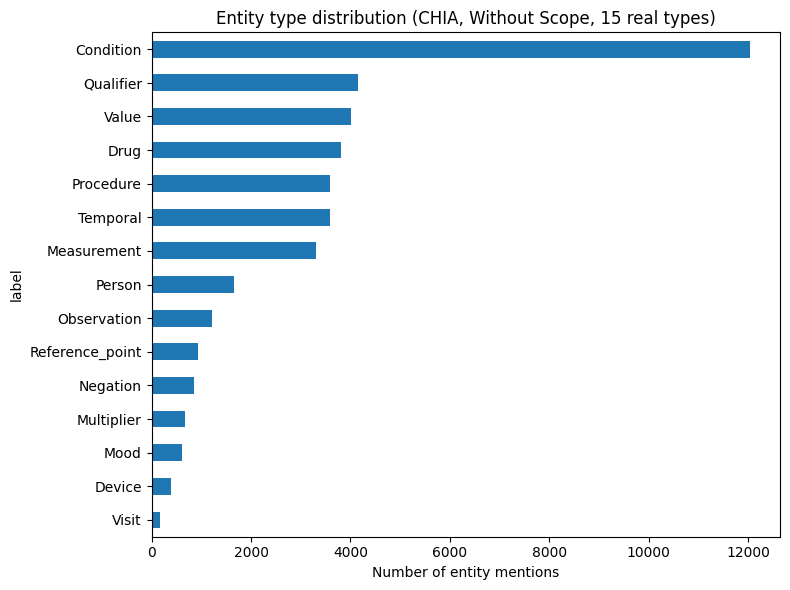

label
Condition          12039
Qualifier           4157
Value               4002
Drug                3801
Procedure           3595
Temporal            3580
Measurement         3305
Person              1666
Observation         1216
Reference_point      934
Negation             843
Multiplier           671
Mood                 616
Device               386
Visit                165
Name: count, dtype: int64


In [36]:
# Class distribution

counts = ents_real.label.value_counts()
ax = counts.sort_values().plot(kind="barh", figsize=(8, 6))
ax.set_title("Entity type distribution (CHIA, Without Scope, 15 real types)")
ax.set_xlabel("Number of entity mentions")
plt.tight_layout(); plt.show()
print(counts)


Condition dominates with 12,039 of 40,976 entities, followed by Qualifier, Value, Drug, Procedure, Temporal and Measurement (roughly 3,300 to 4,200 each). Rare types like Visit (165), Device (386) and Mood (616) have far fewer examples, so a model may do poorly on them while overall accuracy still looks good. Because of this imbalance, I will evaluate each entity type separately (precision, recall, F1) in Stage 4.

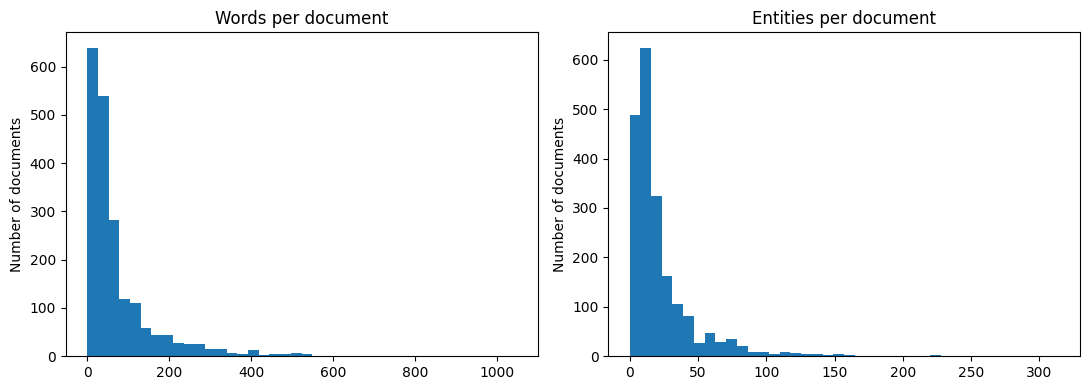

In [37]:
# Document & Criterion Length

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
doc_df.n_words.plot(kind="hist", bins=40, ax=axes[0], title="Words per document")
doc_df.n_entities.plot(kind="hist", bins=40, ax=axes[1], title="Entities per document")
for a in axes: a.set_ylabel("Number of documents")
plt.tight_layout(); plt.show()

Most documents are short but a few are much longer. Long documents might need to be split into smaller pieces because BioBERT can only read a limited number of words at once.

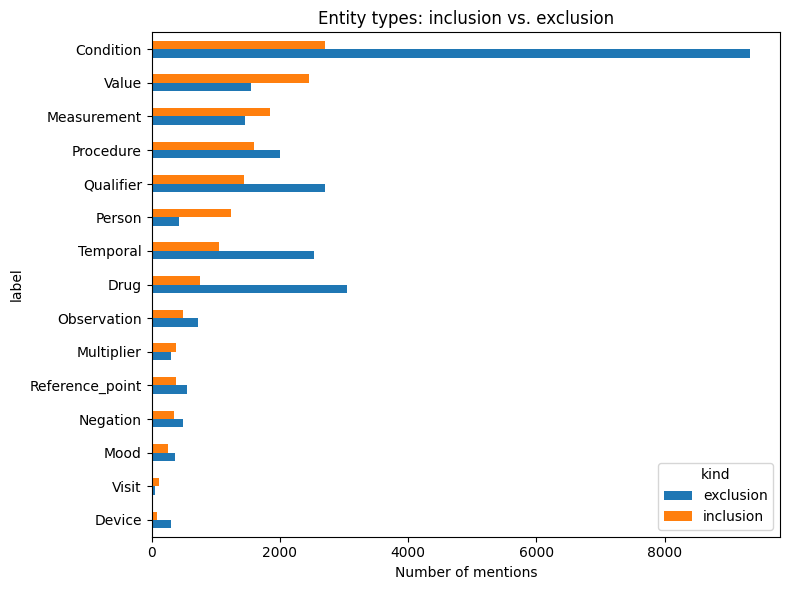

kind
exclusion    25850
inclusion    15126
Name: count, dtype: int64


In [38]:
# Inclusion vs. Exclusion

pd.crosstab(ents_real.label, ents_real.kind).sort_values("inclusion").plot(
    kind="barh", figsize=(8, 6), title="Entity types: inclusion vs. exclusion")
plt.xlabel("Number of mentions"); plt.tight_layout(); plt.show()
print(ents_real.kind.value_counts())


Exclusion criteria contain more entity mentions (25,850 vs.15,126). Condition is most common in exclusion than inclusion criteria.

In [39]:
# Most common Strings per type

for lab in ["Condition", "Drug", "Procedure"]:
    print(f"\n--- Top 10 {lab} ---")
    print(ents[ents.label == lab].text.str.lower().value_counts().head(10))


--- Top 10 Condition ---
text
pregnant             230
pregnancy            195
allergy              192
hypersensitivity     136
contraindication     100
malignancy            83
stroke                83
infection             69
diabetes              67
contraindications     65
Name: count, dtype: int64

--- Top 10 Drug ---
text
aspirin            33
corticosteroids    32
medication         32
prednisone         29
warfarin           27
antibiotics        26
insulin            26
steroids           25
medications        25
study drugs        25
Name: count, dtype: int64

--- Top 10 Procedure ---
text
treatment               157
surgery                  83
chemotherapy             64
treated                  35
mri                      30
general anesthesia       28
radiotherapy             23
contraception            22
radiation therapy        22
physical examination     22
Name: count, dtype: int64


The most common Conditions are pregnancy and allergy-related terms ("pregnant" 230, "pregnancy" 195, "allergy" 192), which makes sense because they are typical exclusion criteria. Drug mentions are very spread out: even the most common drug (aspirin) appears only 33 times, and many are generic words like "medication" or "steroids". Procedures are similar, led by generic words like "treatment" (157) and "surgery" (83). This long tail of varied terms is why a context-aware model like BioBERT is a good fit.

In [40]:
# Overlap

def overlap(a, b):
    return any(s1 < e2 and s2 < e1 for s1, e1 in a["spans"] for s2, e2 in b["spans"])

n_over = n_tot = 0
for d in docs:
    es = [e for e in d["entities"] if e["label"] in REAL_LABELS]
    n_tot += len(es)
    n_over += sum(any(overlap(a, b) for j, b in enumerate(es) if j != i)
                  for i, a in enumerate(es))
print(f"{n_over} of {n_tot} real entities overlap another entity")

5911 of 40976 real entities overlap another entity


5,911 of 40,976 real entities overlap another entity, and 1,796 entities are made of multiple pieces. A standard tagging scheme gives each word only one label, so I'll need some kind of rule for these cases before training.

### **5. Train / Validation / Test Split**

       trials  documents  criteria  entities
split                                       
train     800       1600      9806     32268
val       100        200      1293      4051
test      100        200      1310      4657


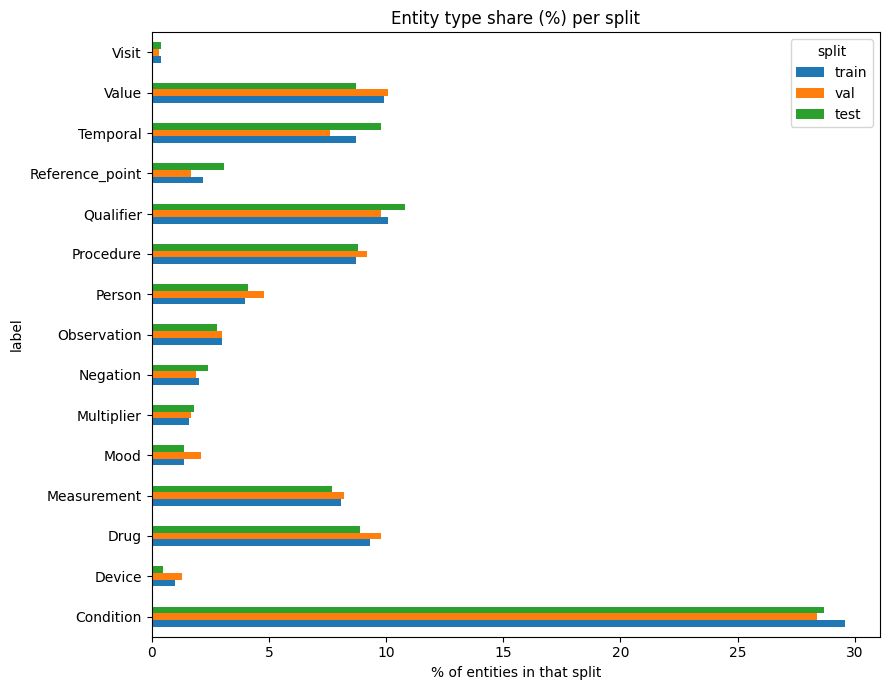

Saved splits.json


In [41]:

# Train / validation / test split (by trial)
import json

trials = sorted(doc_df.trial.unique())
random.Random(SEED).shuffle(trials)

n = len(trials)
n_train, n_val = int(0.8 * n), int(0.1 * n)
split_trials = {
    "train": trials[:n_train],
    "val":   trials[n_train:n_train + n_val],
    "test":  trials[n_train + n_val:],
}

# Safety checks
sets = {k: set(v) for k, v in split_trials.items()}
assert not (sets["train"] & sets["val"])
assert not (sets["train"] & sets["test"])
assert not (sets["val"] & sets["test"])
assert sum(len(v) for v in sets.values()) == n

trial_to_split = {t: s for s, ts in split_trials.items() for t in ts}
doc_df["split"] = doc_df.trial.map(trial_to_split)
ents_real["split"] = ents_real.trial.map(trial_to_split)

summary = pd.DataFrame({
    "trials":    doc_df.groupby("split").trial.nunique(),
    "documents": doc_df.groupby("split").size(),
    "criteria":  doc_df.groupby("split").n_criteria.sum(),
    "entities":  ents_real.groupby("split").size(),
}).loc[["train", "val", "test"]]
print(summary)

# Share of each entity type inside each split (%)
pct = (pd.crosstab(ents_real.label, ents_real.split, normalize="columns") * 100).round(1)
pct[["train", "val", "test"]].plot(kind="barh", figsize=(9, 7),
                                   title="Entity type share (%) per split")
plt.xlabel("% of entities in that split"); plt.tight_layout(); plt.show()

# Saving split for later stages reuse
PROCESSED = PROJECT_DIR + "/data processed "
with open(PROCESSED + "/splits.json", "w") as f:
    json.dump(split_trials, f, indent=2)
print("Saved splits.json")

Trials were split 80/10/10 at random (seed 42), by trial, so the inclusion and exclusion files of the same trial always stay together. This prevents leakage, where the model sees near-identical text in both training and test. Entity-type proportions look similar across the three splits, so the test set is a fair sample.